In [41]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')

torch.backends.cudnn.benchmark = True

In [42]:
# 1. 定义数据预处理
# ToTensor 将图像转换为 [0.0, 1.0] 的张量
# Normalize 可选，通常用于加速训练收敛

#定义归一化参数
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转
    transforms.RandomCrop(32, padding=1),   # 随机裁剪
    transforms.ColorJitter(brightness=0.1,  # 颜色抖动
                           contrast=0.1,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])#(均值)，(标准差)
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])#(均值)，(标准差)
])

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


In [44]:
# 2. 载入训练集 (包含 50000 张图)
# train=True: torchvision 会自动找到并合并 data_batch_1 至 data_batch_5
ROOT_DIR = 'C:/Jupyter(Anaconda)/data'
train_dataset = datasets.CIFAR10(
    root=ROOT_DIR,
    train=True,
    download=False,
    transform=transform
)
# --- 验证加载情况 ---
print(f"数据集大小: {len(train_dataset)}")




数据集大小: 50000


In [45]:
test2_dataset = datasets.CIFAR10(
    root=ROOT_DIR,
    train=False,
    download=False,
    transform=transform_test
)

In [46]:
import torch.nn as nn

In [47]:
#创建数据集的 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,                 # 丢弃最后不足 batch_size 的样本
    num_workers=2,#改为2
    pin_memory=(device.type == "cuda"),
    persistent_workers=True,
    # 新增：预取因子，每个worker预取2批数据
    prefetch_factor=2
)

test2_loader = DataLoader(
    test2_dataset,
    batch_size=1024,
    shuffle=False,
    pin_memory=(device.type == "cuda")
)

In [48]:
'''Args:
    in_channels (int): Number of channels in the input image
    out_channels (int): Number of channels produced by the convolution
    kernel_size (int or tuple): Size of the convolving kernel
    stride (int or tuple, optional): Stride of the convolution. Default: 1
    padding (int, tuple or str, optional): Padding added to all four sides of
            the input. Default: 0
    dilation (int or tuple, optional): Spacing between kernel elements. Default: 1
    groups (int, optional): Number of blocked connections from input
            channels to output channels. Default: 1
    bias (bool, optional): If ``True``, adds a learnable bias to the
            output. Default: ``True``
    padding_mode (str, optional): ``'zeros'``, ``'reflect'``,
            ``'replicate'`` or ``'circular'``. Default: ``'zeros'``'''
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, out_3x3_reduce, out_3x3, out_5x5_reduce, out_5x5, out_pool):
        super(InceptionModule, self).__init__()
        
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        
        # 分支1：1x1卷积
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            nn.BatchNorm2d(out_1x1),#BatchNorm非常关键，从60%提到90%以上
            
        )
        
        # 分支2：
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_3x3_reduce, kernel_size=1),#先1x1降维
            nn.BatchNorm2d(out_3x3_reduce),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_3x3_reduce, out_3x3, kernel_size=3, padding=1),#再3x3卷积
            nn.BatchNorm2d(out_3x3),
            
        )
        
        # 分支3：5x5用padding=2保持尺寸）
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out_5x5_reduce, kernel_size=1),#1x1降维
            nn.BatchNorm2d(out_5x5_reduce),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_5x5_reduce, out_5x5, kernel_size=5, padding=2),#5x5卷积
            nn.BatchNorm2d(out_5x5),
            
        )
        
        # 分支4：3x3池化 -> 1x1卷积调整通道
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool, kernel_size=1),
            nn.BatchNorm2d(out_pool),
            
        )

        # 新增残差捷径
        self.out_channels = out_1x1 + out_3x3 + out_5x5 + out_pool
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, self.out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(self.out_channels)
        )
    def forward(self, x):#更改激活函数位置
        branch_out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)
        residual = self.shortcut(x)
        out = self.activation(branch_out + residual)
        return out

In [49]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.net = nn.Sequential(
            # 前置层：简单卷积+池化，处理32x32输入
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            #输出图像尺寸：32x32(因为padding=1)，通道数：64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),
            
            # 第一个Inception模块组
            InceptionModule(in_channels=64, out_1x1=32, out_3x3_reduce=24, out_3x3=32, out_5x5_reduce=4, out_5x5=8, out_pool=8),
            #输出通道：32+32+8+8=80
            #下一层in_channels与上一层输出通道一致(80)
            InceptionModule(in_channels=80, out_1x1=32, out_3x3_reduce=32, out_3x3=64, out_5x5_reduce=8, out_5x5=16, out_pool=16),
            #输出通道：32+64+16+16=128
            
            nn.MaxPool2d(kernel_size=2, stride=2),  # 下采样：图像尺寸32x32 -> 16x16
            
            # 第二个Inception模块组
            #下一层in_channels与上一层输出通道一致(128)
            InceptionModule(in_channels=128, out_1x1=48, out_3x3_reduce=64, out_3x3=80, out_5x5_reduce=16, out_5x5=32, out_pool=32),
            #输出通道：48+80+32+32=192
            #下一层in_channels与上一层输出通道一致(192)
            InceptionModule(in_channels=192, out_1x1=40, out_3x3_reduce=80, out_3x3=100, out_5x5_reduce=32, out_5x5=40, out_pool=40),
            #输出通道：40+100+40+40=220
            nn.AvgPool2d(kernel_size=2, stride=2),  # 下采样：图像尺寸16x16 -> 8x8
            nn.Conv2d(in_channels=220, out_channels=256, kernel_size=3,padding=1), 
            nn.BatchNorm2d(256),
            nn.LeakyReLU(inplace=True),
            # 分类头：全局平均池化 + 全连接
            nn.AdaptiveAvgPool2d(output_size=(1, 1)),  # 不管输入尺寸，强制输出1x1
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)  # 直接输出10类
        )

    def forward(self, X):
        y = self.net(X)
        return y

In [50]:
Model=CNN().to(device)

In [51]:
%run MulClassSVM.ipynb
loss_fn1=MultiClassSVM()#使用自己写的loss
loss_fn2=nn.CrossEntropyLoss()

In [52]:
learning_rate=0.0021
optimizer=torch.optim.Adam(
    Model.parameters(),
    lr=learning_rate,
    weight_decay=0.001
)
# 余弦退火调度器：随 epoch 平滑降低学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=42,eta_min=0.00001)

Epoch [01/42]  Train Acc: 52.8706%  lr: 2.10e-03
Epoch [02/42]  Train Acc: 67.5280%  lr: 2.09e-03
Epoch [03/42]  Train Acc: 73.0549%  lr: 2.07e-03
Epoch [04/42]  Train Acc: 76.9291%  lr: 2.05e-03
Epoch [05/42]  Train Acc: 79.5633%  lr: 2.03e-03
Epoch [06/42]  Train Acc: 81.4884%  lr: 2.00e-03
Epoch [07/42]  Train Acc: 82.5982%  lr: 1.96e-03
Epoch [08/42]  Train Acc: 83.5677%  lr: 1.92e-03
Epoch [09/42]  Train Acc: 84.5933%  lr: 1.87e-03
Epoch [10/42]  Train Acc: 85.1803%  lr: 1.82e-03
Epoch [11/42]  Train Acc: 85.7131%  lr: 1.77e-03
Epoch [12/42]  Train Acc: 86.2600%  lr: 1.71e-03
Epoch [13/42]  Train Acc: 86.8309%  lr: 1.64e-03
Epoch [14/42]  Train Acc: 87.2276%  lr: 1.58e-03
Epoch [15/42]  Train Acc: 87.8405%  lr: 1.51e-03
Epoch [16/42]  Train Acc: 88.1991%  lr: 1.44e-03
Epoch [17/42]  Train Acc: 88.6639%  lr: 1.36e-03
Epoch [18/42]  Train Acc: 89.3009%  lr: 1.29e-03
Epoch [19/42]  Train Acc: 89.2648%  lr: 1.21e-03
Epoch [20/42]  Train Acc: 90.0661%  lr: 1.13e-03
Epoch [21/42]  Train

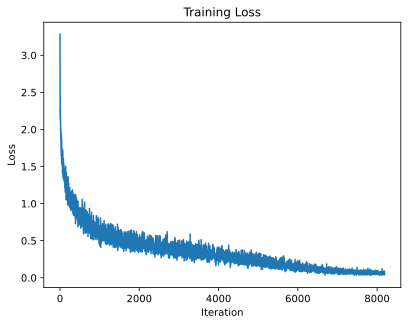

In [53]:
#训练网络
epochs=42
losses=[]
scaler=torch.amp.GradScaler()#混合精度训练的梯度缩放器
for epoch in range(epochs):#9.5min训练
    Model.train() #训练模式
    correct,total=0,0
    for (x,y) in train_loader:#获取小批次x,y
        x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)#清理上一轮滞留的梯度
        with torch.amp.autocast(device_type=device.type):
            Pred=Model(x)#一次前向传播
            loss=0.85*loss_fn2(Pred,y)+0.15*loss_fn1(Pred,y)#计算损失函数
        
        scaler.scale(loss).backward()#一次反向传播
        scaler.step(optimizer)#优化内部参数
        scaler.update()#更新缩放器
        losses.append(loss.item())
        
        correct    += (Pred.argmax(dim=1) == y).sum().item()
        total      += y.size(0)

    scheduler.step()
    train_acc  = correct    / total

    print(f"Epoch [{epoch+1:02d}/{epochs}]  "
          f"Train Acc: {100*train_acc:.4f}%  "
          f"lr: {scheduler.get_last_lr()[0]:.2e}")


# 绘制损失曲线
Fig = plt.figure()
plt.plot(range(len(losses)), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()#98.89% 45epochs

In [ ]:
def evaluate(loader):
    """返回在给定 loader 上的准确率"""
    Model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = Model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    return correct / total

print("正在评估测试集...")#89.77% 25epochs(未完全收敛)，最好时91.17% 42epochs
print(f"测试集准确率：{evaluate(test2_loader)*100:.4f}%")

正在评估测试集...
测试集准确率：90.9100%


In [55]:
#torch.save(Model.state_dict(), "best_Inception5x5.pth")